In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # fixed once, reused everywhere in this notebook

df = pd.read_csv('../data/processed/cleaned_data.csv')
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,none,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,none,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


### Separate Features (X) and Target (y)

In [2]:
X = df.drop(columns=['Risk'])
y = df['Risk']

print(X.shape, y.shape)

(1000, 9) (1000,)


In [3]:
y = y.map({'good': 0, 'bad': 1})
print(y.value_counts())

Risk
0    700
1    300
Name: count, dtype: int64


### Split Data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

Train shape: (800, 9)
Test shape: (200, 9)

Train class distribution:
 Risk
0    0.7
1    0.3
Name: proportion, dtype: float64

Test class distribution:
 Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


## Preprocessing Pipeline

In [5]:
X_train.dtypes

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

### Building the ColumnTransformer

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = ['Age', 'Job', 'Credit amount', 'Duration']
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Placeholder pipeline just to test preprocessing works end-to-end
test_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])

test_pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")

Pipeline fitted successfully!


In [8]:
# How many features after preprocessing (before hitting the model)?
transformed = test_pipeline.named_steps['preprocessor'].transform(X_train)
print("Transformed shape:", transformed.shape)

# Quick sanity check — accuracy on test set with this placeholder model
print("Test accuracy (placeholder LogisticRegression):", test_pipeline.score(X_test, y_test))

Transformed shape: (800, 21)
Test accuracy (placeholder LogisticRegression): 0.73


# Model Building

### Define All Models in a Dictionary

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE)
}

### Build a Pipeline Per Model + Train + Collect Results in a Loop

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

results = []
fitted_pipelines = {}  # we'll need these saved for later phases (ROC curves, feature importance, etc.)

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]  # probability of class 1 ("bad")
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    
    fitted_pipelines[name] = pipe  # store fitted pipeline for later use

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,AdaBoost,0.725,0.571429,0.333333,0.421053,0.773274
1,Logistic Regression,0.730,0.583333,0.350000,0.437500,0.760000
2,Random Forest,0.745,0.615385,0.400000,0.484848,0.748214
3,Decision Tree,0.750,0.586207,0.566667,0.576271,0.697619


In [11]:
print(y_train.dtype)
print(y_train.unique())
print(y_test.unique())

int64
[1 0]
[0 1]


### Model Evaluation

#### Confusion Matrices

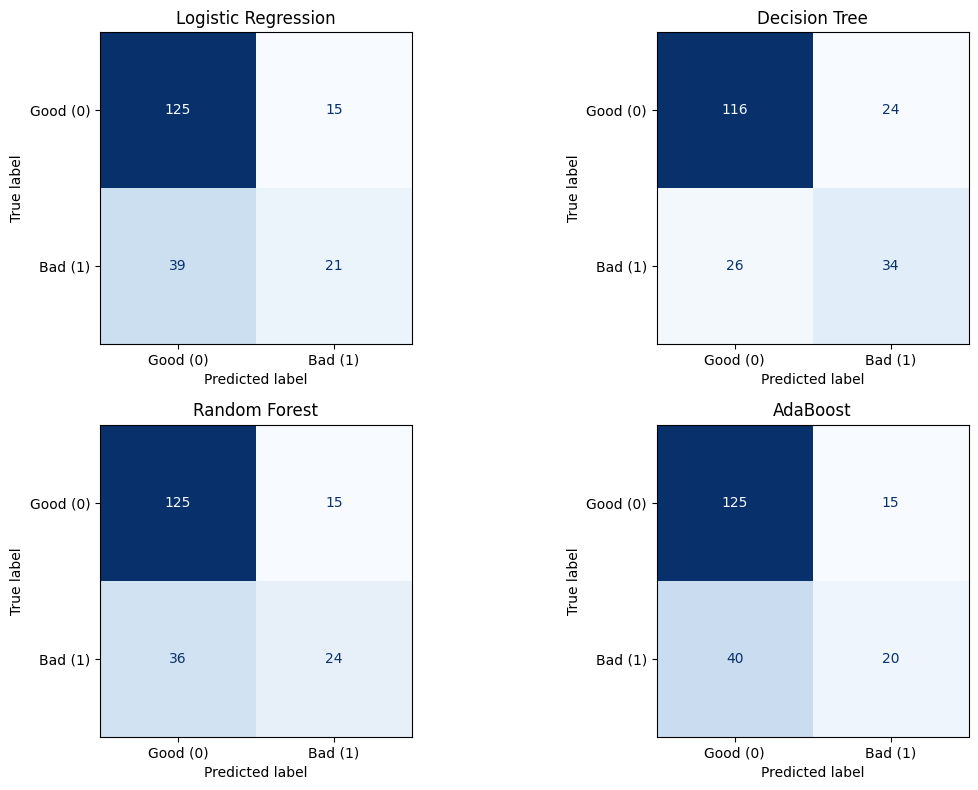

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, pipe) in enumerate(fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

#### ROC Curves

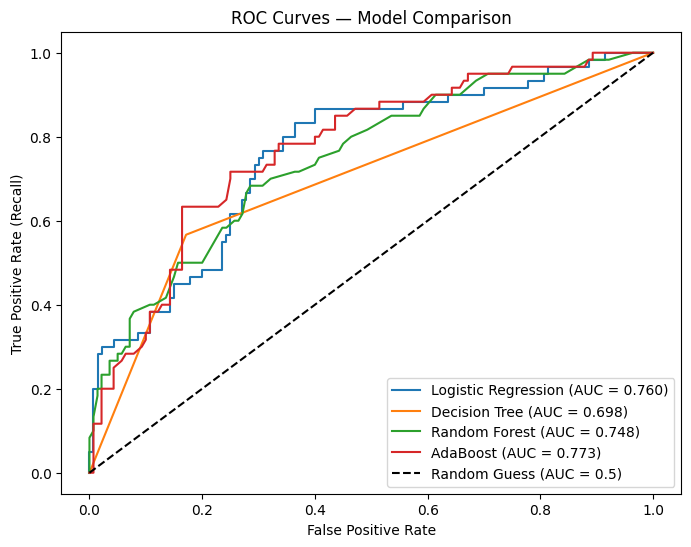

In [13]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.show()

#### Cross-Validation

In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'Mean ROC-AUC': scores.mean(),
        'Std Dev': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('Mean ROC-AUC', ascending=False).reset_index(drop=True)
cv_results_df

,Model,Mean ROC-AUC,Std Dev
0,Logistic Regression,0.746381,0.019060
1,AdaBoost,0.745095,0.031759
2,Random Forest,0.738786,0.036953
3,Decision Tree,0.630000,0.035455


# Hyperparameter Tuning

### Tune Decision Tree (our most urgent case — fix the overfitting)

In [15]:
from sklearn.model_selection import GridSearchCV

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_param_grid = {
    'classifier__max_depth': [3, 4, 5, 6, 7, 8, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10]
}

dt_grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

dt_grid_search.fit(X_train, y_train)

print("Best params:", dt_grid_search.best_params_)
print("Best CV ROC-AUC:", dt_grid_search.best_score_)

Best params: {'classifier__max_depth': 4, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
Best CV ROC-AUC: 0.7194754464285715


### Tune Random Forest

In [16]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 8, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best params:", rf_grid_search.best_params_)
print("Best CV ROC-AUC:", rf_grid_search.best_score_)

Best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.7561011904761904


### Tune AdaBoost

In [17]:
ada_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(random_state=RANDOM_STATE))
])

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0]
}

ada_grid_search = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=ada_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

ada_grid_search.fit(X_train, y_train)

print("Best params:", ada_grid_search.best_params_)
print("Best CV ROC-AUC:", ada_grid_search.best_score_)

Best params: {'classifier__learning_rate': 0.5, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.750483630952381


### Tune Logistic Regression

In [18]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

lr_grid_search.fit(X_train, y_train)

print("Best params:", lr_grid_search.best_params_)
print("Best CV ROC-AUC:", lr_grid_search.best_score_)

Best params: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.7548735119047618


C:\Users\joshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\joshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Feature Importance
The goal here: figure out which features actually drive predictions,

### Feature Importance for Random Forest

In [19]:
# Get the tuned Random Forest pipeline (best_estimator_ from GridSearchCV)
best_rf_pipeline = rf_grid_search.best_estimator_

# Extract feature names after preprocessing
feature_names = best_rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Extract importances from the trained classifier step
importances = best_rf_pipeline.named_steps['classifier'].feature_importances_

# Combine into a clean, sorted dataframe
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_importance_df

,Feature,Importance
0,num__Credit amount,0.206567
1,cat__Checking account_none,0.195360
2,num__Duration,0.169390
3,num__Age,0.128663
4,num__Job,0.040431
5,cat__Saving accounts_none,0.036499
6,cat__Checking account_moderate,0.031819
7,cat__Housing_own,0.031655
8,cat__Sex_male,0.029637
9,cat__Purpose_radio/TV,0.025692


C:\Users\joshi\AppData\Local\Temp\ipykernel_22872\2017505855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance_df.head(top_n), y='Feature', x='Importance', palette='viridis')


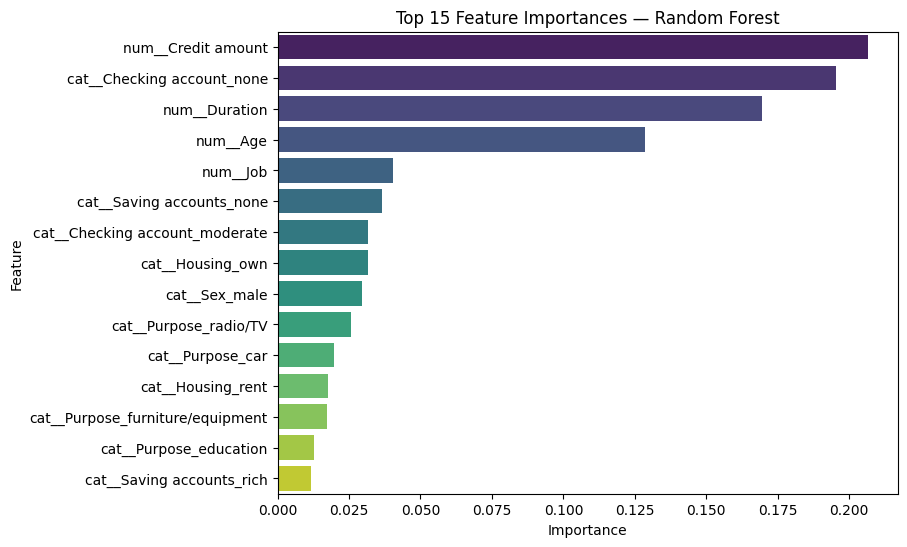

In [20]:
plt.figure(figsize=(8, 6))
top_n = 15
sns.barplot(data=rf_importance_df.head(top_n), y='Feature', x='Importance', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.show()

### Feature Importance for Logistic Regression

In [21]:
best_lr_pipeline = lr_grid_search.best_estimator_

lr_feature_names = best_lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
lr_coefficients = best_lr_pipeline.named_steps['classifier'].coef_[0]

lr_coef_df = pd.DataFrame({
    'Feature': lr_feature_names,
    'Coefficient': lr_coefficients
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

lr_coef_df

,Feature,Coefficient
0,cat__Purpose_education,0.768008
1,num__Duration,0.459530
2,cat__Housing_rent,0.365068
3,cat__Purpose_repairs,0.310361
4,cat__Purpose_car,0.039561
5,num__Credit amount,0.019375
6,cat__Purpose_domestic appliances,0.000000
7,cat__Purpose_furniture/equipment,0.000000
8,cat__Saving accounts_moderate,0.000000
9,cat__Purpose_vacation/others,0.000000


C:\Users\joshi\AppData\Local\Temp\ipykernel_22872\2956881503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_coef_df, y='Feature', x='Coefficient', palette='coolwarm')


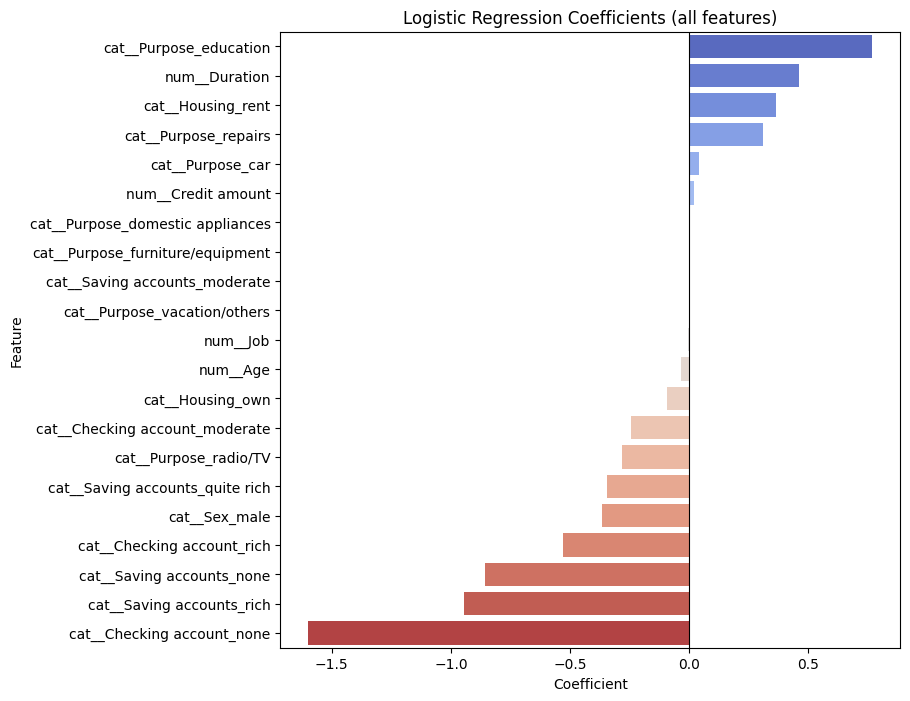

In [22]:
plt.figure(figsize=(8, 8))
sns.barplot(data=lr_coef_df, y='Feature', x='Coefficient', palette='coolwarm')
plt.title('Logistic Regression Coefficients (all features)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# Final Model Selection`

In [23]:
final_model = LogisticRegression(
    C=1,
    penalty='l1',
    solver='liblinear',
    random_state=RANDOM_STATE,
    max_iter=1000
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_model)
])

final_pipeline.fit(X_train, y_train)

# Final check on the untouched test set (first time we use it for the FINAL model)
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

print("Final Test Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Test Precision:", precision_score(y_test, y_pred_final))
print("Final Test Recall:", recall_score(y_test, y_pred_final))
print("Final Test F1:", f1_score(y_test, y_pred_final))
print("Final Test ROC-AUC:", roc_auc_score(y_test, y_proba_final))

Final Test Accuracy: 0.735
Final Test Precision: 0.6
Final Test Recall: 0.35
Final Test F1: 0.4421052631578947
Final Test ROC-AUC: 0.7597619047619047


C:\Users\joshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\joshi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [24]:
# from sklearn.metrics import precision_recall_curve

# # Probability of BAD
# y_proba = final_pipeline.predict_proba(X_test)[:, bad_index]

# precision, recall, thresholds = precision_recall_curve(
#     y_test,
#     y_proba,
#     pos_label="bad"
# )

NameError: name 'bad_index' is not defined

In [ ]:
# sample = pd.DataFrame({
#     "Age": [25],
#     "Job": [2],
#     "Credit amount": [8000],
#     "Duration": [48],
#     "Sex": ["male"],
#     "Housing": ["rent"],
#     "Saving accounts": ["little"],
#     "Checking account": ["none"],
#     "Purpose": ["car"]
# })

# print(final_pipeline.predict(sample))

In [ ]:
print(y.unique())

In [25]:
# Pick one sample from the test set — let's say row index 5 (you can change this)
sample_index = 5

sample_input = X_test.iloc[[sample_index]]  # double brackets keep it as a DataFrame, not a Series
actual_label = y_test.iloc[sample_index]

print("Sample input:")
print(sample_input)
print()
print("Actual label (0=good, 1=bad):", actual_label)

# Predict using our final pipeline
predicted_label = final_pipeline.predict(sample_input)[0]
predicted_proba = final_pipeline.predict_proba(sample_input)[0]

print()
print("Predicted label (0=good, 1=bad):", predicted_label)
print("Predicted probability [P(good), P(bad)]:", predicted_proba)
print(f"Probability of Bad Credit: {predicted_proba[1]*100:.2f}%")

print()
if predicted_label == actual_label:
    print("✅ Correct prediction!")
else:
    print("❌ Incorrect prediction")

Sample input:
     Age   Sex  Job Housing Saving accounts Checking account  Credit amount  \
346   23  male    2     own          little         moderate            882   

     Duration   Purpose  
346        13  radio/TV  

Actual label (0=good, 1=bad): 0

Predicted label (0=good, 1=bad): 0
Predicted probability [P(good), P(bad)]: [0.75323014 0.24676986]
Probability of Bad Credit: 24.68%

✅ Correct prediction!


In [26]:
custom_input = pd.DataFrame([{
    'Age': 35,
    'Sex': 'male',
    'Job': 2,
    'Housing': 'own',
    'Saving accounts': 'little',
    'Checking account': 'moderate',
    'Credit amount': 3000,
    'Duration': 24,
    'Purpose': 'car'
}])

prediction = final_pipeline.predict(custom_input)[0]
probability = final_pipeline.predict_proba(custom_input)[0]

result = "Bad Credit" if prediction == 1 else "Good Credit"
print(f"Prediction: {result}")
print(f"Probability of Bad Credit: {probability[1]*100:.2f}%")

Prediction: Good Credit
Probability of Bad Credit: 40.40%


### Testing on diff inputs

In [27]:
sample_input = pd.DataFrame({
    'Age': [45],
    'Sex': ['male'],
    'Job': [3],
    'Housing': ['own'],
    'Saving accounts': ['rich'],
    'Checking account': ['rich'],
    'Credit amount': [1200],
    'Duration': [12],
    'Purpose': ['radio/TV']
})

predicted_label = final_pipeline.predict(sample_input)[0]
predicted_proba = final_pipeline.predict_proba(sample_input)[0]

print("Predicted Label:", predicted_label)
print("Probability [Good, Bad]:", predicted_proba)
print(f"Probability of Bad Credit: {predicted_proba[1]*100:.2f}%")

Predicted Label: 0
Probability [Good, Bad]: [0.920969 0.079031]
Probability of Bad Credit: 7.90%


In [28]:
sample_input = pd.DataFrame({
    'Age': [22],
    'Sex': ['female'],
    'Job': [0],
    'Housing': ['rent'],
    'Saving accounts': ['none'],
    'Checking account': ['none'],
    'Credit amount': [15000],
    'Duration': [60],
    'Purpose': ['education']
})

predicted_label = final_pipeline.predict(sample_input)[0]
predicted_proba = final_pipeline.predict_proba(sample_input)[0]

print("Predicted Label:", predicted_label)
print("Probability [Good, Bad]:", predicted_proba)
print(f"Probability of Bad Credit: {predicted_proba[1]*100:.2f}%")

Predicted Label: 1
Probability [Good, Bad]: [0.37882354 0.62117646]
Probability of Bad Credit: 62.12%


In [29]:
sample_input = pd.DataFrame({
    'Age': [32],
    'Sex': ['male'],
    'Job': [2],
    'Housing': ['free'],
    'Saving accounts': ['moderate'],
    'Checking account': ['moderate'],
    'Credit amount': [5000],
    'Duration': [24],
    'Purpose': ['car']
})

predicted_label = final_pipeline.predict(sample_input)[0]
predicted_proba = final_pipeline.predict_proba(sample_input)[0]

print("Predicted Label:", predicted_label)
print("Probability [Good, Bad]:", predicted_proba)
print(f"Probability of Bad Credit: {predicted_proba[1]*100:.2f}%")

Predicted Label: 0
Probability [Good, Bad]: [0.56734747 0.43265253]
Probability of Bad Credit: 43.27%


In [30]:
# Test : 1
# Predicted Label: 0
# Probability [Good, Bad]: [0.920969 0.079031]
# Probability of Bad Credit: 7.90%

# Test : 2
# Predicted Label: 1
# Probability [Good, Bad]: [0.37882354 0.62117646]
# Probability of Bad Credit: 62.12%

# Test : 3
# Predicted Label: 0
# Probability [Good, Bad]: [0.56734747 0.43265253]
# Probability of Bad Credit: 43.27%

In [31]:
import joblib

# Save to the models/ folder (as per our folder structure)
joblib.dump(final_pipeline, '../models/credit_risk_pipeline.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [32]:
# Load it back fresh, as if we were in a brand new script/app
loaded_pipeline = joblib.load('../models/credit_risk_pipeline.pkl')

# Re-run the same custom input test through the LOADED pipeline
test_prediction = loaded_pipeline.predict(custom_input)[0]
test_probability = loaded_pipeline.predict_proba(custom_input)[0]

result = "Bad Credit" if test_prediction == 1 else "Good Credit"
print(f"Loaded pipeline prediction: {result}")
print(f"Probability of Bad Credit: {test_probability[1]*100:.2f}%")

Loaded pipeline prediction: Good Credit
Probability of Bad Credit: 40.40%


In [33]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1 Score':<12}")
print("-" * 48)

for t in [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{t:<12}{p:<12.3f}{r:<12.3f}{f:<12.3f}")

Threshold   Precision   Recall      F1 Score    
------------------------------------------------
0.5         0.600       0.350       0.442       
0.45        0.490       0.400       0.440       
0.4         0.484       0.517       0.500       
0.35        0.507       0.617       0.556       
0.3         0.512       0.717       0.597       
0.25        0.490       0.817       0.613       
0.2         0.442       0.883       0.589       


In [34]:
THRESHOLD = 0.25

def predict_with_threshold(pipeline, input_df, threshold=THRESHOLD):
    proba = pipeline.predict_proba(input_df)[0][1]
    label = "Bad Credit" if proba >= threshold else "Good Credit"
    return label, round(proba * 100, 2)


# ---- Test 1: A few real rows from X_test, compare old (0.5) vs new (0.25) ----
print("=== Real X_test rows: Default (0.5) vs New Threshold (0.25) ===\n")

for idx in [5, 20, 45, 70]:  # pick a few different row indices
    sample = X_test.iloc[[idx]]
    actual = y_test.iloc[idx]
    proba = final_pipeline.predict_proba(sample)[0][1]

    old_label = "Bad Credit" if proba >= 0.5 else "Good Credit"
    new_label = "Bad Credit" if proba >= THRESHOLD else "Good Credit"

    actual_label = "Bad Credit" if actual == 1 else "Good Credit"

    print(f"Row {idx}: Actual = {actual_label} | Probability = {proba*100:.2f}%")
    print(f"   Old (0.5): {old_label}   |   New (0.25): {new_label}")
    print(f"   {'⚠️  Prediction changed' if old_label != new_label else '— No change'}\n")


# ---- Test 2: Same custom profiles we used back in Phase 10 ----
print("\n=== Custom profiles ===\n")

custom_profiles = {
    "Low Risk Profile": {
        'Age': 45, 'Sex': 'male', 'Job': 3, 'Housing': 'own',
        'Saving accounts': 'rich', 'Checking account': 'rich',
        'Credit amount': 1500, 'Duration': 12, 'Purpose': 'radio/TV'
    },
    "Medium Risk Profile": {
        'Age': 40, 'Sex': 'male', 'Job': 2, 'Housing': 'rent',
        'Saving accounts': 'moderate', 'Checking account': 'moderate',
        'Credit amount': 3200, 'Duration': 20, 'Purpose': 'furniture/equipment'
    },
    "High Risk Profile": {
        'Age': 22, 'Sex': 'female', 'Job': 1, 'Housing': 'rent',
        'Saving accounts': 'little', 'Checking account': 'little',
        'Credit amount': 8000, 'Duration': 48, 'Purpose': 'education'
    }
}

for name, profile in custom_profiles.items():
    sample = pd.DataFrame([profile])
    proba = final_pipeline.predict_proba(sample)[0][1]
    old_label = "Bad Credit" if proba >= 0.5 else "Good Credit"
    new_label = "Bad Credit" if proba >= THRESHOLD else "Good Credit"

    print(f"{name}: Probability = {proba*100:.2f}%")
    print(f"   Old (0.5): {old_label}   |   New (0.25): {new_label}")
    print(f"   {'⚠️  Prediction changed' if old_label != new_label else '— No change'}\n")

=== Real X_test rows: Default (0.5) vs New Threshold (0.25) ===

Row 5: Actual = Good Credit | Probability = 24.68%
   Old (0.5): Good Credit   |   New (0.25): Good Credit
   — No change

Row 20: Actual = Good Credit | Probability = 6.51%
   Old (0.5): Good Credit   |   New (0.25): Good Credit
   — No change

Row 45: Actual = Good Credit | Probability = 5.14%
   Old (0.5): Good Credit   |   New (0.25): Good Credit
   — No change

Row 70: Actual = Bad Credit | Probability = 14.04%
   Old (0.5): Good Credit   |   New (0.25): Good Credit
   — No change


=== Custom profiles ===

Low Risk Profile: Probability = 7.92%
   Old (0.5): Good Credit   |   New (0.25): Good Credit
   — No change

Medium Risk Profile: Probability = 46.54%
   Old (0.5): Good Credit   |   New (0.25): Bad Credit
   ⚠️  Prediction changed

High Risk Profile: Probability = 91.87%
   Old (0.5): Bad Credit   |   New (0.25): Bad Credit
   — No change



In [35]:
from sklearn.metrics import accuracy_score

y_pred_025 = (y_proba >= 0.25).astype(int)
print("Accuracy at threshold 0.25:", accuracy_score(y_test, y_pred_025))

Accuracy at threshold 0.25: 0.69
